# HW 5

## Q1

1. A model is linear in its parameters (coefficients). The predictors can be transformed but the coefficients must enter the model linearly.

2. It represents the difference in the predicted outcome between that category and the reference (omitted) category, holding other variables constant.

3. Yes, however it is not ideal. Linear regression predicts continuous values and can output values outside [0,1], so it is not appropriate for modeling probabilities so in this case logistic regression is preferred.

4. Model has very high training accuracy but poor test/validation performance, large variance in predictions across samples, too many predictors relative to data size, the model is highly sensitive to small changes in data.

5. In the first stage, regress one correlated predictor on the others to isolate its independent variation. In the second stage, use the predicted values in the main regression. If predictors are highly collinear, the first stage shows one variable is largely explained by others, leading to inflated coefficients in the second stage.

6. You can add transformed features, use interaction terms, or use basis expansions.

7. The intercept is the expected value of the outcome when all predictors equal 0. The slope coefficient is the change in the outcome for a one unit increase in that variable, holding others constant. A dummy variable coefficient is the difference in outcome between that category and the reference category, holding others constant.

## Q2

                    Price  Review Scores Rating
Neighbourhood                                  
Bronx           75.276498             91.654378
Brooklyn       127.747378             92.363497
Manhattan      183.664286             91.801496
Queens          96.857233             91.549057
Staten Island  146.166667             90.843750


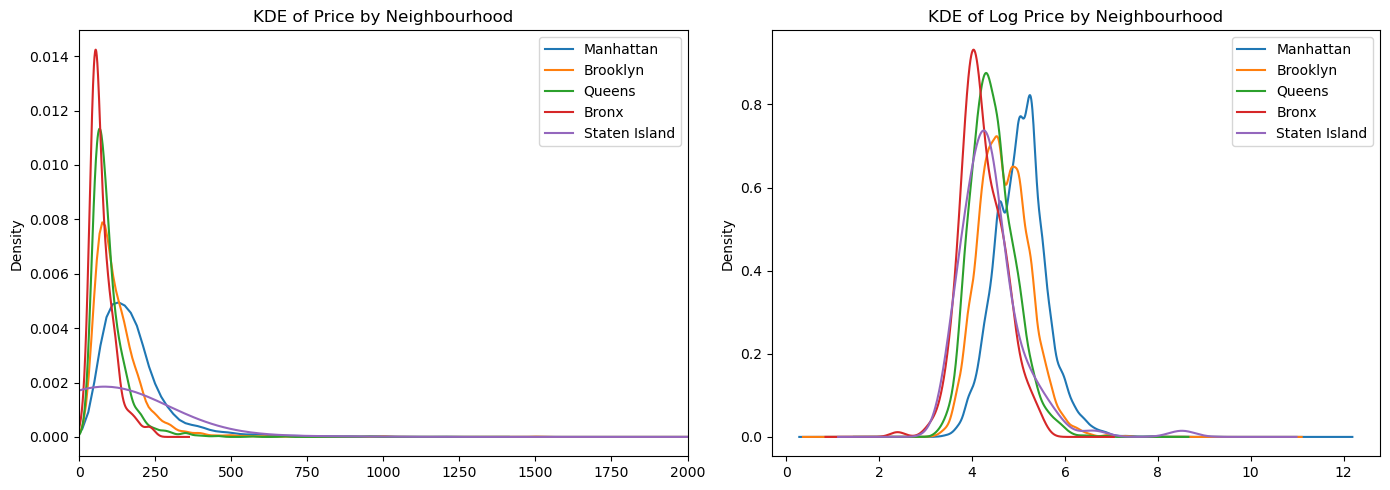

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

clean = pd.read_csv('./Q1_clean.csv')
clean = clean.rename(columns={'Neighbourhood ': 'Neighbourhood'})

# 1
print(clean.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for n in clean['Neighbourhood'].unique():
    subset = clean[clean['Neighbourhood'] == n]
    subset['Price'].plot.kde(ax=axes[0], label=n)
    np.log1p(subset['Price']).plot.kde(ax=axes[1], label=n)
 
axes[0].set_title('KDE of Price by Neighbourhood')
axes[0].set_xlim(0, 2000)
axes[0].legend()
axes[1].set_title('KDE of Log Price by Neighbourhood')
axes[1].legend()
plt.tight_layout()
plt.show()

Manhattan is the most expensive at $183.66/night average.

In [12]:
# 2
X2 = pd.get_dummies(clean['Neighbourhood'], drop_first=False).astype(float)
model2 = LinearRegression(fit_intercept=False)
model2.fit(X2, clean['Price'])
print(pd.Series(model2.coef_, index=X2.columns))
 

Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
dtype: float64


With no intercept and all dummies, the coefficients exactly equal the group means from the first part. When you regress a continuous variable on a single categorical variable, each coefficient is just the conditional mean of that group.

In [14]:
# 3
X3 = pd.get_dummies(clean['Neighbourhood'], drop_first=True).astype(float)
model3 = LinearRegression(fit_intercept=True)
model3.fit(X3, clean['Price'])
print(model3.intercept_)
print(pd.Series(model3.coef_, index=X3.columns))

75.2764976958471
Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64


With an intercept, you must drop one dummy to avoid perfect multicollinearity. The intercept is 75.28 which is the mean price of the reference borough. Each slope = price difference vs. Bronx. To get the coefficients from part 2 you add the intercept to each slope; the reference borough's part 2 coefficient equals the intercept.

In [16]:
# 4
q2_4 = pd.get_dummies(clean['Neighbourhood'], drop_first=True).astype(float)
q2_4['Review Scores Rating'] = clean['Review Scores Rating']
q2_4['Price'] = clean['Price']
q2_4 = q2_4.dropna()

X4, y4 = q2_4.drop(columns='Price'), q2_4['Price']
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42)
 
model4 = LinearRegression(fit_intercept=True)
model4.fit(X4_train, y4_train)
y4_pred = model4.predict(X4_test)
 
print(r2_score(y4_test, y4_pred))
print(root_mean_squared_error(y4_test, y4_pred))
print(pd.Series(model4.coef_, index=X4.columns))

0.045925883817347524
140.91821103729367
Brooklyn                 51.555970
Manhattan               107.413553
Queens                   20.198573
Staten Island            23.454672
Review Scores Rating      1.211852
dtype: float64


R² = 0.046, RMSE = 140.92. Coefficient on Review Scores Rating = 1.21. Most expensive borough: Manhattan.

In [17]:
q2_5 = pd.get_dummies(clean[['Neighbourhood', 'Property Type']], drop_first=True).astype(float)
q2_5['Review Scores Rating'] = clean['Review Scores Rating']
q2_5['Price'] = clean['Price']
q2_5 = q2_5.dropna()
 
X5, y5 = q2_5.drop(columns='Price'), q2_5['Price']
X5_train, X5_test, y5_train, y5_test = train_test_split(X5, y5, test_size=0.2, random_state=42)
 
model5 = LinearRegression(fit_intercept=True)
model5.fit(X5_train, y5_train)
y5_pred = model5.predict(X5_test)
 
print(r2_score(y5_test, y5_pred))
print(root_mean_squared_error(y5_test, y5_pred))
print(pd.Series(model5.coef_, index=X5.columns))


0.054242713551242216
140.30266238276306
Neighbourhood_Brooklyn            59.633702
Neighbourhood_Manhattan          121.005520
Neighbourhood_Queens              26.830617
Neighbourhood_Staten Island       15.700974
Property Type_Bed & Breakfast    -28.703920
Property Type_Boat                47.070419
Property Type_Bungalow            83.972440
Property Type_Cabin               12.389621
Property Type_Camper/RV          -13.817125
Property Type_Castle             -41.810548
Property Type_Chalet             -30.237720
Property Type_Condominium         61.907162
Property Type_Dorm               -42.277758
Property Type_House               34.711346
Property Type_Hut               -134.604484
Property Type_Lighthouse         -91.438731
Property Type_Loft                69.891025
Property Type_Other               49.249761
Property Type_Townhouse           44.110768
Property Type_Treehouse           10.325182
Property Type_Villa               33.901468
Review Scores Rating               1

R² = 0.054, RMSE = 140.30. Coefficient on Review Scores Rating = 1.20. Most expensive property type: Bungalow.

6
The rating coefficient changed slightly because adding Property Type controls for omitted variable bias. In part 4, the rating coefficient was absorbing price variation actually caused by property type. Part 5 isolates the pure effect of rating holding property type fixed.

## Q3

count    956.000000
mean      13.409512
std        0.427445
min       12.509874
25%       13.087254
50%       13.409795
75%       13.684547
max       14.497597
Name: log_Price, dtype: float64


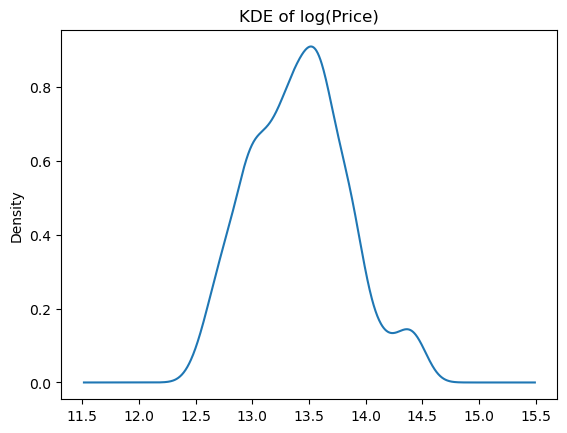

               count          mean            std        min        25%  \
Make                                                                      
Chevrolet        5.0  4.908000e+05  256093.147116   273000.0   335000.0   
Datsun           3.0  2.896667e+05   10503.967504   279000.0   284500.0   
Ford            52.0  7.211731e+05  140927.699605   290000.0   635000.0   
Honda           73.0  7.989726e+05  266509.066586   316000.0   581000.0   
Hyundai        303.0  6.947525e+05  277837.000404   273000.0   491000.0   
Jeep             4.0  1.499500e+06  152513.387391  1290000.0  1447500.0   
Kia              8.0  1.614750e+06  119056.709177  1369000.0  1579000.0   
MG Motors       27.0  1.830333e+06  110937.959100  1589000.0  1767000.0   
Mahindra        18.0  1.100167e+06  175549.305961   796000.0  1037000.0   
Maruti Suzuki  288.0  5.946146e+05  213253.690825   271000.0   416500.0   
Nissan           4.0  8.842500e+05  289559.867155   475000.0   782500.0   
Renault         68.0  6.6

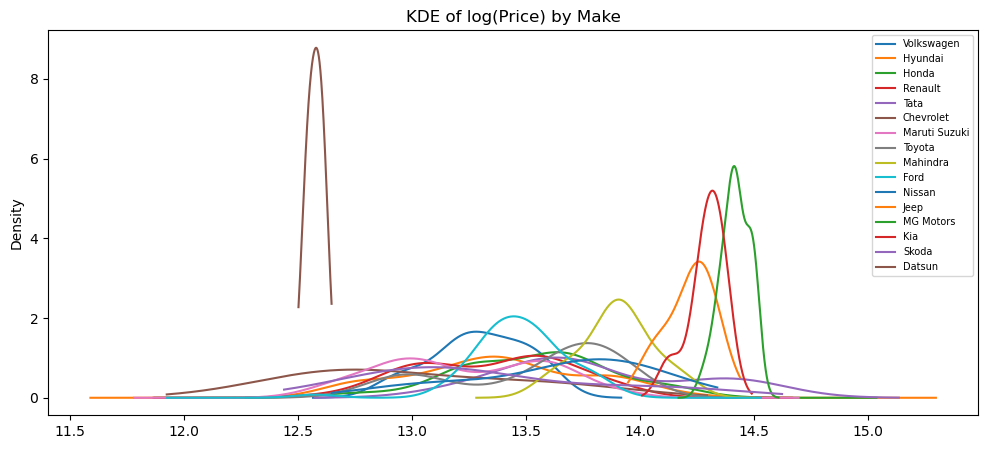

In [27]:
cars = pd.read_csv('./cars_hw.csv', index_col=0)

# 1
cars['Transmission_Speeds'] = cars['Transmission'].str.extract(r'(\d+)').astype(float).fillna(0)
cars = cars.drop(columns='Transmission')
 
cars['No_of_Owners'] = cars['No_of_Owners'].map({'1st': 1, '2nd': 2, '3rd': 3})
 
# Log-transform Price and Mileage_Run
cars['log_Price'] = np.log(cars['Price'])
cars['log_Mileage_Run'] = np.log(cars['Mileage_Run'])
 
# Drop extreme Price outliers
lo, hi = cars['Price'].quantile(0.01), cars['Price'].quantile(0.99)
cars = cars[(cars['Price'] >= lo) & (cars['Price'] <= hi)].reset_index(drop=True)

# 2
print(cars['log_Price'].describe())
 
cars['log_Price'].plot.kde()
plt.title('KDE of log(Price)')
plt.show()
 
print(cars.groupby('Make')['Price'].describe())
 
fig, ax = plt.subplots(figsize=(12, 5))
for make in df['Make'].unique():
    cars[cars['Make'] == make]['log_Price'].plot.kde(ax=ax, label=make)
ax.legend(fontsize=7)
ax.set_title('KDE of log(Price) by Make')
plt.show()

Most expensive brands are MG Motors, Kia, Jeep. Prices look right-skewed with log(Price) being much more bell-shaped.

In [25]:
# 3
num_cols = ['Make_Year', 'log_Mileage_Run', 'No_of_Owners', 'Seating_Capacity', 'Transmission_Speeds']
cat_cols  = ['Make', 'Color', 'Body_Type', 'Fuel_Type', 'Transmission_Type']
 
X_num = cars[num_cols]
X_cat = pd.get_dummies(cars[cat_cols], drop_first=True).astype(float)
X_all = pd.concat([X_num, X_cat], axis=1)
y = cars['log_Price']

idx = np.arange(len(X_all)) 
idx_train, idx_test = train_test_split(idx, test_size=0.2, random_state=42)
 
X_num_train, X_num_test = X_num.iloc[idx_train], X_num.iloc[idx_test]
X_cat_train, X_cat_test = X_cat.iloc[idx_train], X_cat.iloc[idx_test]
X_all_train, X_all_test = X_all.iloc[idx_train], X_all.iloc[idx_test]
y_train,      y_test    = y.iloc[idx_train],      y.iloc[idx_test]

In [ ]:
# 4
# Model 1
X_num = cars[['Make_Year', 'log_Mileage_Run', 'No_of_Owners', 'Seating_Capacity', 'Transmission_Speeds']]
X_num_train, X_num_test, y_train, y_test = train_test_split(X_num, y, test_size=0.2, random_state=42)
m1 = LinearRegression().fit(X_num_train, y_train)
print(r2_score(y_test, m1.predict(X_num_test)))
print(root_mean_squared_error(y_test, m1.predict(X_num_test)))

# Model 2
X_cat = pd.get_dummies(cars[['Make', 'Color', 'Body_Type', 'Fuel_Type', 'Transmission_Type']], drop_first=True).astype(float)
X_cat_train, X_cat_test = X_cat.iloc[X_num_train.index], X_cat.iloc[X_num_test.index]

m2 = LinearRegression().fit(X_cat_train, y_train)
print(r2_score(y_test, m2.predict(X_cat_test)))
print(root_mean_squared_error(y_test, m2.predict(X_cat_test)))

# Model 3
X_all_train = pd.concat([X_num_train, X_cat_train], axis=1)
X_all_test  = pd.concat([X_num_test, X_cat_test], axis=1)

m3 = LinearRegression().fit(X_all_train, y_train)
print(r2_score(y_test, m3.predict(X_all_test)))
print(root_mean_squared_error(y_test, m3.predict(X_all_test)))

0.458410535168415
0.28313960831148594
0.4833809296649796
0.2765354035089873
0.7891895983692286
0.1766491454708274


Numeric only model: R² = 0.458, RMSE = 0.283
Categorical only model: R² = 0.483, RMSE = 0.277
Combined: R² = 0.789, RMSE = 0.177 — far better, the two sets of features are complementary

In [ ]:
# 5
for deg in range(2, 7):
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    Xp_train = np.hstack([poly.fit_transform(X_num_train), X_cat_train])
    Xp_test  = np.hstack([poly.transform(X_num_test), X_cat_test])
    m = LinearRegression().fit(Xp_train, y_train)
    print(f"Degree {deg} R2: {r2_score(y_test, m.predict(Xp_test)):.4f}  RMSE: {root_mean_squared_error(y_test, m.predict(Xp_test)):.4f}")

Degree 2 R2: 0.7981  RMSE: 0.1729
Degree 3 R2: -20.3088  RMSE: 1.7760
Degree 4 R2: -0.2494  RMSE: 0.4301
Degree 5 R2: -3.3342  RMSE: 0.8010
Degree 6 R2: -3.2470  RMSE: 0.7929


Once you go past Degree 3, the R2 and RMSE all become negative. Degree 2 gives the best results with an R2 of 0.7981 and RMSE of 0.1729, which is slightly better than the combined linear model from part 4. 

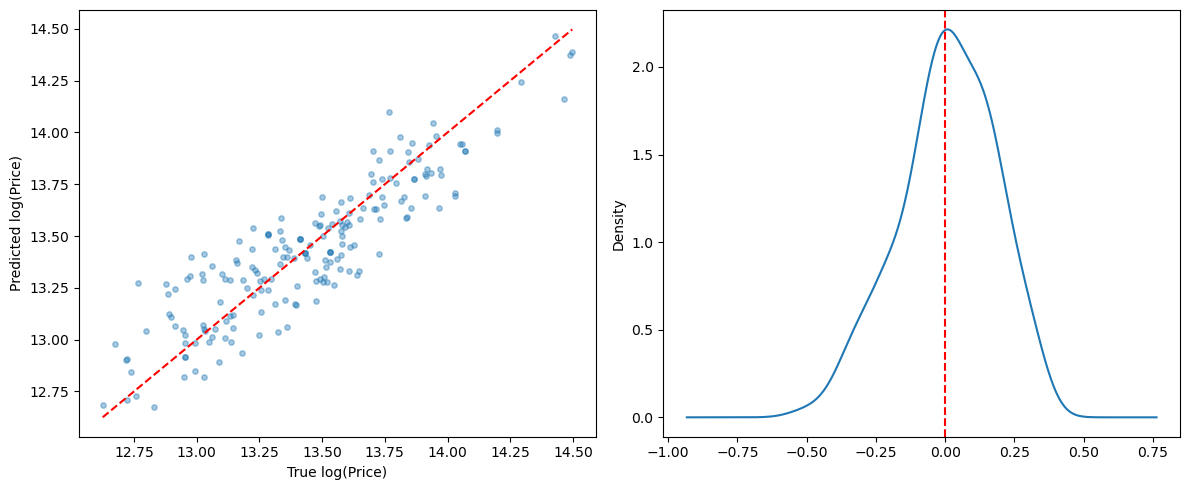

In [43]:
# 6
poly2 = PolynomialFeatures(degree=2, include_bias=False)
Xp2_train = np.hstack([poly2.fit_transform(X_num_train), X_cat_train])
Xp2_test  = np.hstack([poly2.transform(X_num_test), X_cat_test])
m_best = LinearRegression().fit(Xp2_train, y_train)

y_pred = m_best.predict(Xp2_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, y_pred, alpha=0.4, s=15)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set_xlabel('True log(Price)')
axes[0].set_ylabel('Predicted log(Price)')

residuals.plot.kde(ax=axes[1])
axes[1].axvline(0, color='r', linestyle='--')
plt.tight_layout()
plt.show()

The predicted vs. true values cluster closely to the diagonal, and the residuals are roughly centered at zero with a bell shape curve. Any systematic deviation would show as a curve away from the diagonal. The model performs reasonably well with an R² of around 0.8 and residuals centered near zero, suggesting it captures the main drivers of price. However, the wide scatter around the diagonal and the left-skewed residuals indicate it struggles with extreme prices, particularly underestimating the most expensive cars.